# <font color="brown">**Heritage Institute of Technology**
# <font color="brown">**Department of AEIE**
# <font color="brown">**MACHINE LEARNING TECHNIQUES LAB (AEI3262)**
# <font color="brown">**B. Tech AEIE,   6th Semester**
# <font color="Blue">**Experiment No. 5: Classification using k-Nearest Neighbors </font>**  **[CO: AEI3262.3]**


# <font color="Blue">**Objective:**  


##Apply k-NN for classification and analyze model behavior with different k values.
- To train k-NN classifier on a dataset (e.g., Iris, Breast Cancer).
- To evaluate performance for different k values: 3, 5, 7, 9, 11, 13, and 15.
- To plot accuracy vs. k, and select optimal value of k for the model.
- To evaluate model performance in terms of accuracy, precision, recall and F1-score.
- visualize learned decision boundary in 2D (if applicable or by talking PCA features in 2D).



# <font color="Blue"> **A: Learning Outcome:**
## After completion of this assignment you will be able to:

*  Apply KNN classifier model on a given data set.
*  Compute the performance of the model in terms of accuracy, precision, recall and F1-score.
* Visualize the decision boundary of the learned model in 2D.


# <font color="Blue">**B. Instructions:**
* You will be using Python 3.
* Avoid using for-loops and while-loops, unless you are explicitly told to do so.
* Do not modify the function name, variable names, comments in cells.
* Write your code where it is asked to write.
* After your coding, run the cell and see your results.

# <font color="Blue">**C. Useful PYTHON Commands**
Some useful PYTHON commands that may be required to perform this experiment are given below:
# <font color="magenta">*Requird Library:*
    numpy     pands    sklearn    matplotlib.pyplot

# <font color="magenta"> *Elementary Functions from numpy:*
    np.unique()        np.meshgrid()    np.arange()    np.c_  

# <font color="magenta">*Functions from matplotlib.pyplot:*
    plt.figure()   plt.plot()     plt.scatter()  plt.title()
    plt.xlabel()   plt.ylabel()   plt.xticks()   plt.yticks()  
    plt.legend()   plt.grid()     plt.show()     plt.text()
    plt.bar()      plt.contourf()

# <font color="magenta"> *Elementary Functions from Seaborn:*
    sns.heatmap()

# <font color="magenta">*Modules and Methods of sklearn library:*
    sklearn.preprocessing.MinMaxScaler()
    scaler.transform()
    sklearn.neighbors.KNeighborsClassifier()
    model.fit()
    model.predict()
    sklearn.model_selection.train_test_split()
    sklearn.metrics.confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
    sklearn.decomposition.PCA()
         

# *For detail information of the regressions modules of sklearn see the following link:*
https://scikit-learn.org/stable/modules/linear_model.html

# <font color="green">**1. Introduction: <font color="green">**
The **k-Nearest Neighbors (KNN)** algorithm is a **supervised machine learning technique** used for both **classification** and **regression** problems. It is a **non-parametric** and **instance-based (lazy learning) algorithm**, meaning it does not assume any prior distribution about the data and does not explicitly build a model during training.

In classification tasks, KNN assigns a class label to a new data point based on the **majority class** among its k nearest neighbors in the feature space.

# <font color="green">**2. Basic Working Principle <font color="green">**

Given: Let the training dataset be: $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}$,

where:
* $𝑥_𝑖∈𝑅^p$ is a feature vector
* $y_i∈{1,2,3,....,C}$ is the class label
* $n$ is the number of training samples
* $p$ is the number of features

For a new test sample $x∈R^p$, the goal is to predict its class label $\hat{y}$.

**The steps of KNN are:**

* Compute the distance between $𝑥$ and all training samples.
* Select the $k$ closest neighbors of $x$.
* Assign the class label of the test sample by majority voting:
            $\hat{y}​=mode(y_{(1)}​,y_{(2)}​,…,y_{(k)​})$.

# <font color="green">**3. Distance measure <font color="green">**

The most commonly used distance metric is Euclidean distance: $d(x_i, x_j) = \sqrt{\sum_{l=1}^{p} (x_{il} - x_{jl})^2}
$.

Other possible distance metrics are:
* Manhattan distance
* Minkowski distance
* Cosine similarity

In general, the Minkowski distance is given by:

$d(x_i, x_j) = \left( \sum_{l=1}^{p} |x_{il} - x_{jl}|^r \right)^{\frac{1}{r}}
$

Where:

* $p$ = number of features
* $r≥1$ = Minkowski parameter
* $r=1 →$ Manhattan distance
* $r=2 →$ Euclidean distance

# <font color="green">**4. Role of Parameter $k$ <font color="green">**

* Small $k →$ Low bias, high variance (may overfit)
* Large $k →$ High bias, low variance (may underfit)
* Choosing optimal $k$ is crucial and is usually done using validation or test accuracy.

# <font color="green">**5. Characteristics of KNN <font color="green">**

* Non-parametric (no assumption about data distribution)
* Lazy learning algorithm (no explicit training phase)
* Instance-based learning
* Sensitive to feature scaling
* Works well for small to medium datasets
* Naturally handles multi-class classification

# <font color="green">**6. Computational Complexity <font color="green">**

Let:
$n$ = number of training samples
$p$ = number of features

**Training Complexity:**

Since KNN stores the dataset and does not train a model:

Training Complexity = $𝑂(1)$

**Testing Complexity:**

For each test sample:

Distance computation: $O(np)$

Sorting neighbors: $O(n\; log\;n)$

Thus,

Prediction Complexity $≈𝑂(𝑛𝑝)$

For large datasets, this becomes computationally expensive.

# <font color="green">**7. Advantages <font color="green">**

* Simple and easy to implement
* No training phase
* Works well with multi-class problems
* Effective when decision boundary is irregular.

# <font color="green">**8. Disadvantages <font color="green">**

* High memory usage
* Slow prediction for large datasets
* Sensitive to irrelevant features
* Sensitive to feature scaling
* Performance degrades in high dimensions (Curse of Dimensionality)

# <font color="green">**9. Curse of Dimensionality <font color="green">**

As dimensionality increases:

* Distance between points becomes less meaningful.
* All points tend to become equidistant.
* Classification performance may degrade.

Therefore, dimensionality reduction techniques like PCA are often applied before KNN.

##<font color="blue"> **Problem-1:**</font> Implement KNN classifier on real-world **breast cancer** dataset using Scikit-learn.

i) Load the dataset and check number of samples, features, categories and distribution of samples.

ii) Split the dataset into training and testing sets in the ratio of 70:30, visualize sample distribution in training and testing sets; and normalize within [0 1].

iii) Implement the KNN classifier using different values of $k=3, 5, 7, 9, 11, 13, 15$, tabulate results and show variation of accuracy with $k$. Interpret the results and analyze how the choice of $k$ affects model performance.

iv) Determine the optimal value of $k$ based on highest classification accuracy.

v) Evaluate the performance of the model using optimal $k$ value, visualize
Confusion Matrix and calculate (a) Accuracy (b) Precision (c) Recall and (d)
F1-score.

vi) Visualize the decission boundary learned by the KNN classifier in 2-D taking PCA features of training set.

# <font color="magenta"> **Step 1: Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer       ##For breast cancer data set
from sklearn.model_selection import train_test_split  ##For train-test splitting
from sklearn.preprocessing import MinMaxScaler        ##For data normalization
from sklearn.neighbors import KNeighborsClassifier    ##For KNN classifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score ##For performance
from sklearn.decomposition import PCA                 ## For PCA


# <font color="magenta"> **Step 2: Load Dataset and Split (train: test=70:30)**

In [ ]:
##Problem- 1.(i):
##Load dataset, check the available keys in the dataset and analyze it
Data = load_breast_cancer()
Data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
##Separate Features and Targets. Check number of samples, features, class labels, etc.
##===========================================
## ~~~ Write two lines of code here ~~~
X= Data['data']
y= Data['target']

##Check data shape, number of samples and number of features
##===========================================
## ~~~ Write three lines of code here ~~~
Data_shape = X.shape
No_samples = X.shape[0]
No_features = X.shape[1]

##Print
print("Shape of data set:", Data_shape)
print("Number of samples:", No_samples)
print("Number of features:", No_features)

##Check shape of target, category names and no. of category
##===========================================
## ~~~ Write three lines of code here ~~~
target_shape = y.shape
class_names = Data.target_names
No_classes = len(class_names)

##Print
print("Shape of targets:", target_shape)
print("Number of classes:", No_classes)
print("Class names:", class_names)


##Count number of samples per class
##===========================================
## ~~~ Write one line of code here ~~~
unique, counts = np.unique(y, return_counts=True)

##Print number of samples per classes
for label, count in zip(unique, counts):
    print(f"Class {class_names[label]}: {count} samples")

##Print the name of features of the dataset
print("Feature names:")
print(Data.feature_names)


Shape of data set: (569, 30)
Number of samples: 569
Number of features: 30
Shape of targets: (569,)
Number of classes: 2
Class names: ['malignant' 'benign']
Class malignant: 212 samples
Class benign: 357 samples
Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


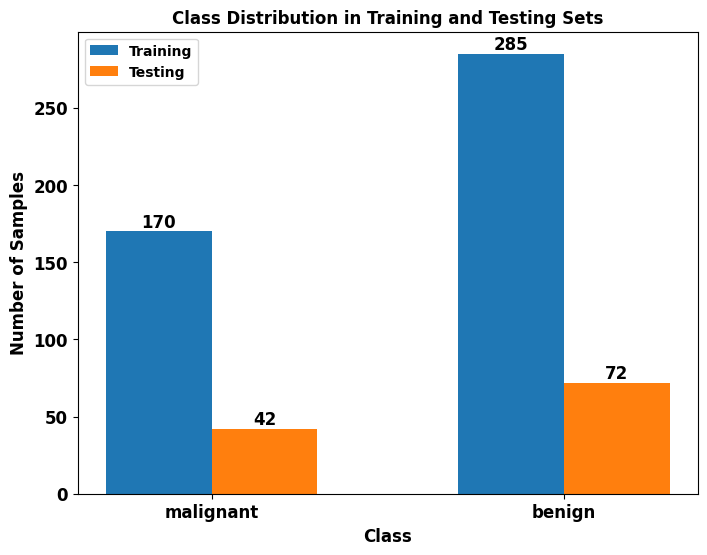

In [ ]:
##Problem- 1.(ii):
## Perform Train-test split (70% train, 30% test) with stratified sampling
##===========================================
## ~~~ Write one line of code here ~~~
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

##Count number of samples in training and testing sets
##===========================================
## ~~~ Write two lines of code here ~~~
train_unique, train_counts = np.unique(y_train, return_counts=True)
test_unique, test_counts = np.unique(y_test, return_counts=True)

##Visualize class distribution of samples by bar plot in training and testing sets
plt.figure(figsize=[8, 6])
width = 0.30
x = np.arange(len(class_names))

##Plot training (bars1) and testing bars (bars2)
##===============================================
## ~~~ Write two lines of code here ~~~
bars1 = plt.bar(x - width/2, train_counts, width, label="Training")
bars2 = plt.bar(x + width/2, test_counts, width, label="Testing")

##Set labels, titles
plt.xticks(x, class_names, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.xlabel("Class", fontsize=12, fontweight='bold')
plt.ylabel("Number of Samples", fontsize=12, fontweight='bold')
plt.title("Class Distribution in Training and Testing Sets", fontsize=12, fontweight='bold')
plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='upper left')

## Add sample counts on top of respective bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()


# <font color="magenta"> **Step 3: Normalize data w.r.t training set**

In [ ]:
##Call MinMaxScaler to normalize within [0, 1] and fit scaler to training data and
## apply on test data
##===============================================
## ~~~ Write three lines of code here ~~~
scaler = MinMaxScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


# <font color="magenta"> **Step 4: Train KNN classifier for different k values**

In [ ]:
##Problem- 1.(iii):
##Set an array for k_values and initialize cointainer to store results
k_values = [3, 5, 7, 9, 11, 13, 15]
results = []

##Start a loop to train KNN classifier for each value of k on normalized training set
## and predict result on normalized test set
for k in k_values:
    ##===========================================================
    ## ~~~ Write two lines of code here ~~~
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    ##Predict trained KNN model on test set and calculate accuracy
    ##============================================================
    ## ~~~ Write two lines of code here ~~~
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    ##Append the k-value and accuracy in the 'results' container
    ##==========================================================
    ## ~~~ Write one line of code here ~~~
    results.append([k, acc])

##Form a dataframe taking the k-value and test accuracy
##==========================================================
## ~~~ Write one line of code here ~~~
results_df = pd.DataFrame(results, columns=["k", "Accuracy"])

##Print the reasult in a table:
print('Testing set accuracy for different k:\n')
results_df


Testing set accuracy for different k:



,k,Accuracy
0,3,0.964912
1,5,0.982456
2,7,0.973684
3,9,0.964912
4,11,0.973684
5,13,0.982456
6,15,0.973684


# <font color="magenta"> **Step 5: Plot Accuracy vs k**

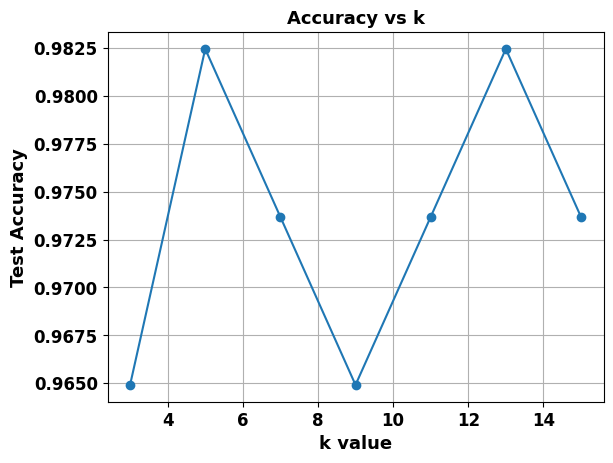

In [ ]:
##Plot a graph to show variation of accuracy with k
plt.figure()
##==========================================================
## ~~~ Write one line of code here ~~~
plt.plot(results_df["k"], results_df["Accuracy"], marker='o')

##Set titles, labels, etc.
plt.xlabel("k value", fontsize=13, fontweight='bold')
plt.ylabel("Test Accuracy", fontsize=13, fontweight='bold')
plt.xticks(size=12, fontweight='bold')
plt.yticks(size=12, fontweight='bold')
plt.title("Accuracy vs k", fontsize=13, fontweight='bold')
plt.grid(True)
plt.show()



# <font color="magenta"> **Step 6: Select Optimal k**

In [ ]:
##Problem- 1.(iv):
##Search the index of highest accuracy in the result dataframe and corresponding value of k
##==========================================================
## ~~~ Write two lines of code here ~~~
best_index = results_df["Accuracy"].idxmax()
optimal_k = results_df.loc[best_index, "k"]

##Print optimal value of k
print("Optimal k:", optimal_k)


Optimal k: 5


# <font color="magenta"> **Step 7: Train Final Model with Optimal k**

In [ ]:
##Problem- 1.(v):
##Train knn classifier using optimal value of k on training set
##==========================================================
## ~~~ Write two lines of code here ~~~
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train_scaled, y_train)

##Predict class labels on test set
##==========================================================
## ~~~ Write one line of code here ~~~
y_test_pred = knn_model.predict(X_test_scaled)


# <font color="magenta"> **Step 8: Display Confusion Matrix and print Performance Metrics**

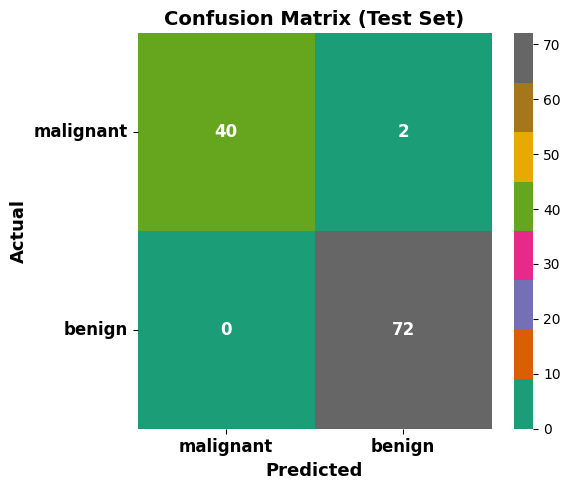

KNN model Performance Metrics on Test Set:
Accuracy : 0.9824561403508771
Precision: 0.972972972972973
Recall   : 1.0
F1-Score : 0.9863013698630136


In [ ]:
##Calculate confusion matrix
##==========================================================
## ~~~ Write one line of code here ~~~
cm = confusion_matrix(y_test, y_test_pred)

##Visualize confusion matrix using heatmap() function of seaborn library
plt.figure(figsize=(6,5))
ax = sns.heatmap(cm, annot=True, fmt='d',
    cmap='Dark2',   # Change color here (e.g., 'Greens', 'Reds', 'coolwarm', 'viridis', 'Set1', 'Dark2')
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 12, "weight": "bold"}  #Bold numbers inside matrix
)

##Make axis labels Bold
plt.xlabel("Predicted", fontsize=13, fontweight='bold')
plt.ylabel("Actual", fontsize=13, fontweight='bold')
plt.title("Confusion Matrix (Test Set)", fontsize=14, fontweight='bold')

##Make tick labels bold
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

plt.tight_layout()
plt.show()

##Calculate performance metrics- accuracy, precision, recall and F1-score
##==========================================================
## ~~~ Write four lines of code here ~~~
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

##Print performance metrics
print("KNN model Performance Metrics on Test Set:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

# <font color="magenta"> **Step 9: Visualize learned KNN model decision boundary using PCA (2 Components) of training data**


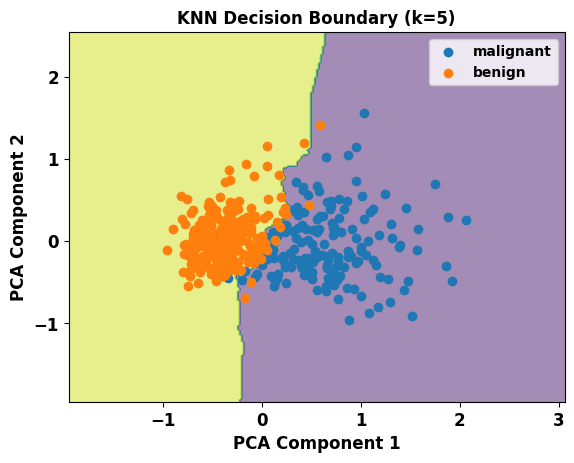

In [ ]:
##Problem- 1.(vi):
##Apply PCA on training set and project data in 2D-space
##Call PCA() function and set for 2 components, apply PCA on training data
## and transform test data in 2D
##==========================================================
## ~~~ Write three lines of code here ~~~
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

##Set KNN classifier for optimal k value and train it using PCA features of training set
##==========================================================
## ~~~ Write two lines of code here ~~~
knn_pca = KNeighborsClassifier(n_neighbors=optimal_k)
knn_pca.fit(X_train_pca, y_train)

##Create 2D sample grid points for testing
##Set range of features using minimum and maximum value of PCA features
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

##Create mesh grid points for test samples
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

##Arrange x and y- coordinates in two columns by caoncatenating and treat each
## row as a feature,then predict the class labels of test points with trained
## the KNN classifier. Reshape the predicted output according to shape of XX or yy
##=============================================================================
## ~~~ Write two lines of code here ~~~
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

##Visualize decision boundary of learned KNN model using contourf()
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.5)

##Scatter plot training samples in 2D with legends
for class_value, class_name in enumerate(class_names):
    plt.scatter(
        X_train_pca[y_train == class_value, 0],
        X_train_pca[y_train == class_value, 1],
        label=class_name
    )

plt.xlabel("PCA Component 1", fontsize=12, fontweight='bold')
plt.ylabel("PCA Component 2", fontsize=12, fontweight='bold')
plt.title(f"KNN Decision Boundary (k={optimal_k})", fontsize=12, fontweight='bold')
plt.xticks(size=12, fontweight='bold')
plt.yticks(size=12, fontweight='bold')
plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='upper right')
plt.show()



## <font color="Green"> **Assignment:**</font>
# 1. Write codes where it is asked to write, run the programs and explain the program outcomes or obtained figures for each problem.